CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


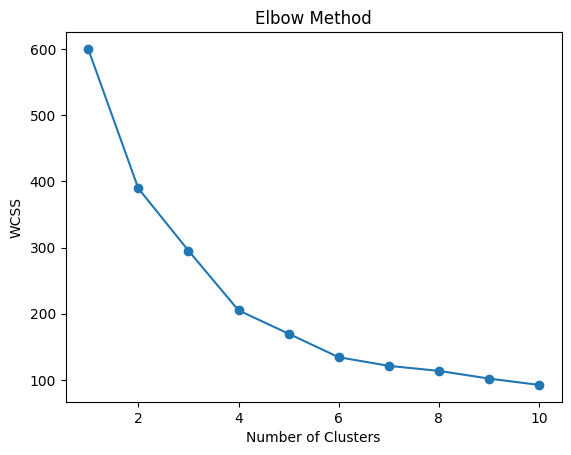

Silhouette Score: 0.40846873777345605


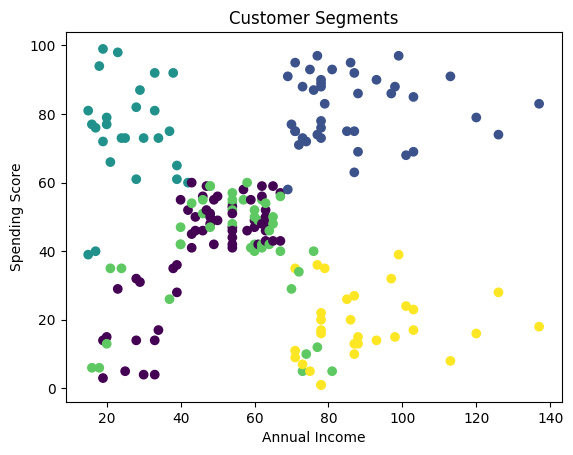

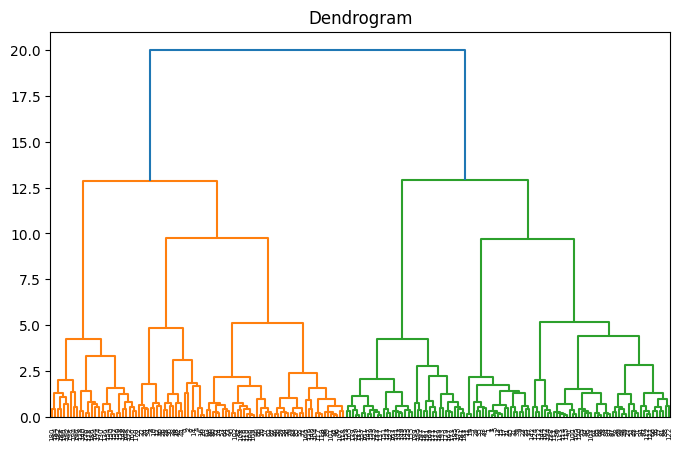

               Age  Annual Income (k$)  Spending Score (1-100)  \
Cluster                                                          
0        55.275862           47.620690               41.706897   
1        32.875000           86.100000               81.525000   
2        25.769231           26.115385               74.846154   
3        26.733333           54.311111               40.911111   
4        44.387097           89.774194               18.483871   

         Number of Customers  
Cluster                       
0                         58  
1                         40  
2                         26  
3                         45  
4                         31  


In [2]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# 2. Load Dataset
df = pd.read_csv("Mall_Customers.csv")

# 3. Check Missing Values
print(df.isnull().sum())

# 4. Select Features
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# 5. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# 7. Apply KMeans (K = 5 from elbow)
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 8. Silhouette Score
score = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", score)

# 9. Cluster Visualization (Income vs Spending)
plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['Cluster'])
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')
plt.show()

# 10. Hierarchical Clustering Dendrogram
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

# 11. Cluster Summary (for interpretation)
cluster_summary = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Number of Customers'})

print(cluster_summary)

In [3]:
cluster_summary = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Number of Customers'}).round(2)

print(cluster_summary)

for i, row in cluster_summary.iterrows():
    print(f"\nCluster {i}")
    print(f"Average Age: {row['Age']}")
    print(f"Average Income: {row['Annual Income (k$)']} k$")
    print(f"Average Spending Score: {row['Spending Score (1-100)']}")
    print(f"Number of Customers: {int(row['Number of Customers'])}")

           Age  Annual Income (k$)  Spending Score (1-100)  \
Cluster                                                      
0        55.28               47.62                   41.71   
1        32.88               86.10                   81.53   
2        25.77               26.12                   74.85   
3        26.73               54.31                   40.91   
4        44.39               89.77                   18.48   

         Number of Customers  
Cluster                       
0                         58  
1                         40  
2                         26  
3                         45  
4                         31  

Cluster 0
Average Age: 55.28
Average Income: 47.62 k$
Average Spending Score: 41.71
Number of Customers: 58

Cluster 1
Average Age: 32.88
Average Income: 86.1 k$
Average Spending Score: 81.53
Number of Customers: 40

Cluster 2
Average Age: 25.77
Average Income: 26.12 k$
Average Spending Score: 74.85
Number of Customers: 26

Cluster 3
Average Age